1. Агрегация mde.parquet на уровень пользователя

Сначала агрегируем данные за 8 недель по каждому пользователю:

In [2]:
import pandas as pd
import numpy as np
from scipy import stats

# Читаем файлы
mde = pd.read_parquet('mde.parquet')
hom = pd.read_parquet('homogenuity.parquet')
res = pd.read_parquet('result.parquet')

# Агрегируем mde на уровень пользователя
user_stats = mde.groupby('user_id').agg({
    'orders_sum': 'sum',
    'gmv_sum': 'sum'
}).reset_index()

print("Агрегированные данные (первые 5 строк):")
print(user_stats.head())
print(f"\nВсего уникальных пользователей в mde: {len(user_stats)}")

Агрегированные данные (первые 5 строк):
                            user_id  orders_sum   gmv_sum
0  00003687F40AB9B083E16D4417A0EC1F    11180.00  11180.00
1  00003A1CA9A9BBB2F510EB1C3F675327     3748.75   3748.75
2  0000552533CF55CFA753DC58A5081F3D    11543.75   3727.50
3  0000667A56DF76742838400BA34606BD     1622.50   1622.50
4  0000B41B9AB1A87D7532D14A737F2E66    32782.50      0.00

Всего уникальных пользователей в mde: 768802


2. Расчет дисперсии по метрикам

In [5]:
# Расчет дисперсии и стандартного отклонения
orders_var = user_stats['orders_sum'].var()
orders_std = user_stats['orders_sum'].std()
gmv_var = user_stats['gmv_sum'].var()
gmv_std = user_stats['gmv_sum'].std()

print("=" * 60)
print("ДИСПЕРСИЯ МЕТРИК")
print("=" * 60)
print(f"orders_sum - Дисперсия: {orders_var:,.2f}, Станд.отклонение: {orders_std:,.2f}")
print(f"gmv_sum    - Дисперсия: {gmv_var:,.2f}, Станд.отклонение: {gmv_std:,.2f}")
print(f"Среднее orders_sum: {user_stats['orders_sum'].mean():,.2f}")
print(f"Среднее gmv_sum: {user_stats['gmv_sum'].mean():,.2f}")
print(f"Доля нулей в gmv_sum: {(user_stats['gmv_sum'] == 0).mean() * 100:.1f}%")

ДИСПЕРСИЯ МЕТРИК
orders_sum - Дисперсия: 82,469,828.97, Станд.отклонение: 9,081.29
gmv_sum    - Дисперсия: 6,890,551.07, Станд.отклонение: 2,624.99
Среднее orders_sum: 8,349.11
Среднее gmv_sum: 2,400.09
Доля нулей в gmv_sum: 34.6%


3. Размеры групп из result.parquet

In [8]:
# Размеры групп из result.parquet
group_sizes = res['grp'].value_counts().sort_index()
print("\n" + "=" * 60)
print("РАЗМЕРЫ ГРУПП В RESULT.PARQUET")
print("=" * 60)
for grp, size in group_sizes.items():
    print(f"{grp:20}: {size:>8,} пользователей")

control_size = group_sizes['control']
avg_test_size = group_sizes[group_sizes.index != 'control'].mean()

print(f"\nКонтрольная группа: {control_size:,.0f}")
print(f"Средний размер тестовых групп: {avg_test_size:,.0f}")


РАЗМЕРЫ ГРУПП В RESULT.PARQUET
1prc_decrease       :  191,954 пользователей
1prc_increase       :  187,106 пользователей
3prc_decrease       :  196,417 пользователей
3prc_increase       :  183,368 пользователей
5prc_decrease       :  201,669 пользователей
5prc_increase       :  178,648 пользователей
control             :  189,717 пользователей

Контрольная группа: 189,717
Средний размер тестовых групп: 189,860


4. Расчет MDE

In [11]:
def calculate_mde(std, n, alpha=0.05, power=0.8):
    """
    Расчет MDE (Minimum Detectable Effect)
    MDE = (z_alpha + z_beta) * sqrt(2 * sigma^2 / n)
    """
    # z-значения для alpha и power
    z_alpha = stats.norm.ppf(1 - alpha/2)  # двусторонний тест
    z_beta = stats.norm.ppf(power)
    
    # Формула MDE
    mde = (z_alpha + z_beta) * np.sqrt(2 * std**2 / n)
    return mde

# Параметры
n = control_size  # используем размер контрольной группы

# Расчет MDE без поправки (alpha = 0.05)
mde_orders = calculate_mde(orders_std, n, alpha=0.05)
mde_gmv = calculate_mde(gmv_std, n, alpha=0.05)

# С поправкой Бонферрони (6 тестов)
alpha_bonf = 0.05 / 6
mde_orders_bonf = calculate_mde(orders_std, n, alpha=alpha_bonf)
mde_gmv_bonf = calculate_mde(gmv_std, n, alpha=alpha_bonf)

# Процентный MDE относительно среднего
mean_orders = user_stats['orders_sum'].mean()
mean_gmv = user_stats['gmv_sum'].mean()

print("\n" + "=" * 60)
print("МИНИМАЛЬНО ДЕТЕКТИРУЕМЫЙ ЭФФЕКТ (MDE)")
print("=" * 60)
print("\nБЕЗ ПОПРАВКИ (alpha = 0.05):")
print(f"orders_sum: {mde_orders:,.2f} ₽ ({mde_orders/mean_orders*100:.2f}%)")
print(f"gmv_sum:    {mde_gmv:,.2f} ₽ ({mde_gmv/mean_gmv*100:.2f}%)")

print("\nС ПОПРАВКОЙ БОНФЕРРОНИ (alpha = 0.05/6 = 0.0083):")
print(f"orders_sum: {mde_orders_bonf:,.2f} ₽ ({mde_orders_bonf/mean_orders*100:.2f}%)")
print(f"gmv_sum:    {mde_gmv_bonf:,.2f} ₽ ({mde_gmv_bonf/mean_gmv*100:.2f}%)")


МИНИМАЛЬНО ДЕТЕКТИРУЕМЫЙ ЭФФЕКТ (MDE)

БЕЗ ПОПРАВКИ (alpha = 0.05):
orders_sum: 82.61 ₽ (0.99%)
gmv_sum:    23.88 ₽ (0.99%)

С ПОПРАВКОЙ БОНФЕРРОНИ (alpha = 0.05/6 = 0.0083):
orders_sum: 102.61 ₽ (1.23%)
gmv_sum:    29.66 ₽ (1.24%)


5. Проверка распределений

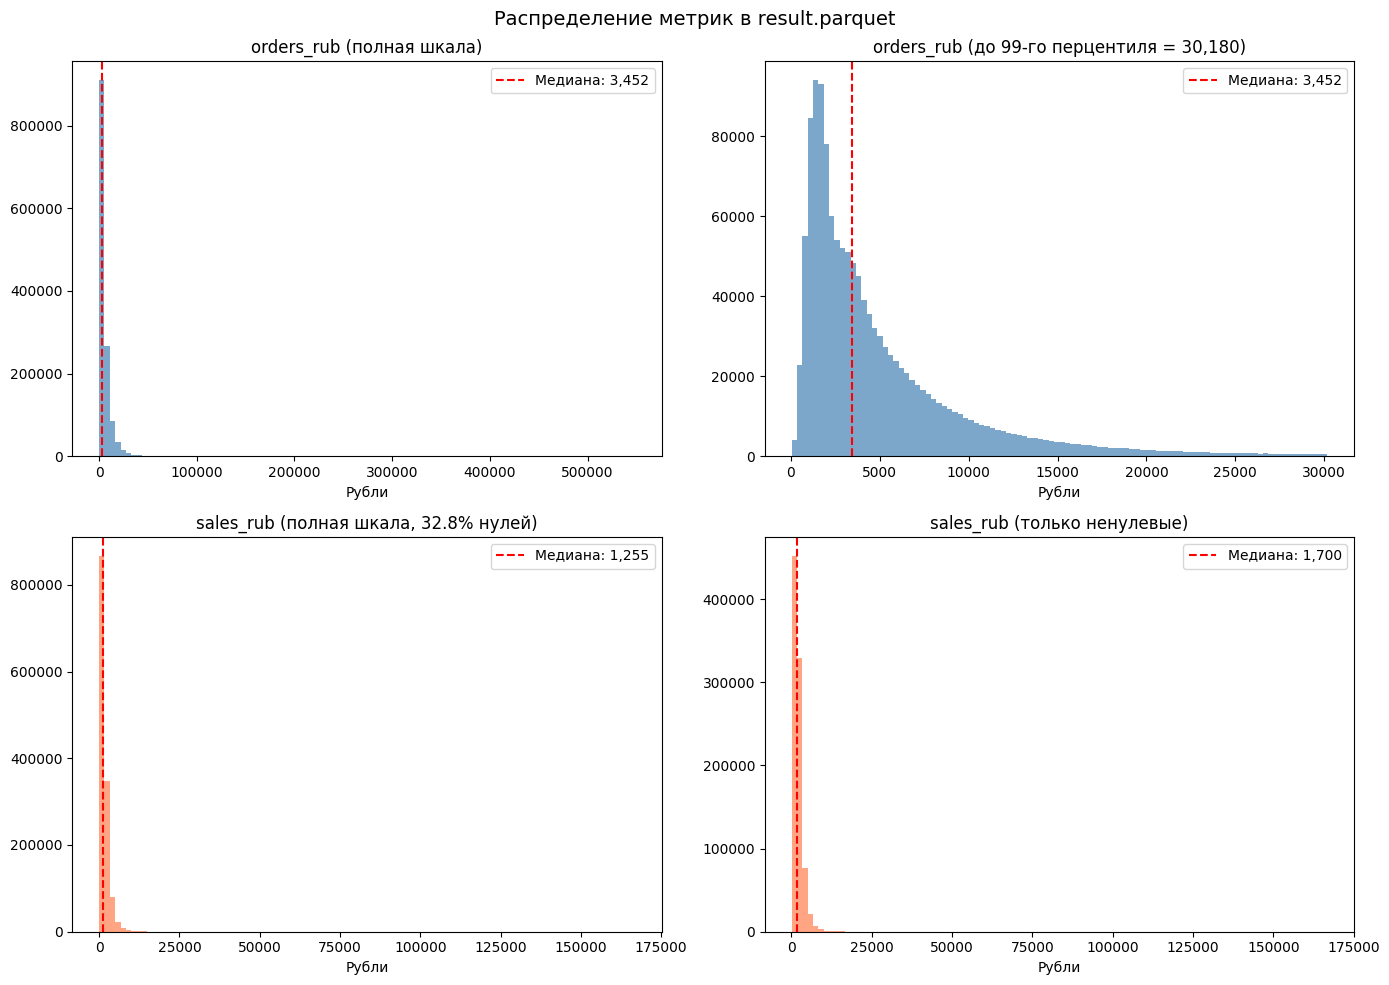

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Распределение метрик в result.parquet', fontsize=14)

# orders_rub
axes[0, 0].hist(res['orders_rub'], bins=100, alpha=0.7, color='steelblue')
axes[0, 0].axvline(res['orders_rub'].median(), color='red', linestyle='--', label=f"Медиана: {res['orders_rub'].median():,.0f}")
axes[0, 0].set_title('orders_rub (полная шкала)')
axes[0, 0].set_xlabel('Рубли')
axes[0, 0].legend()

# orders_rub (ограниченный)
orders_99 = res['orders_rub'].quantile(0.99)
axes[0, 1].hist(res[res['orders_rub'] <= orders_99]['orders_rub'], bins=100, alpha=0.7, color='steelblue')
axes[0, 1].axvline(res['orders_rub'].median(), color='red', linestyle='--', label=f"Медиана: {res['orders_rub'].median():,.0f}")
axes[0, 1].set_title(f'orders_rub (до 99-го перцентиля = {orders_99:,.0f})')
axes[0, 1].set_xlabel('Рубли')
axes[0, 1].legend()

# sales_rub
axes[1, 0].hist(res['sales_rub'], bins=100, alpha=0.7, color='coral')
axes[1, 0].axvline(res['sales_rub'].median(), color='red', linestyle='--', label=f"Медиана: {res['sales_rub'].median():,.0f}")
zero_pct = (res['sales_rub'] == 0).mean() * 100
axes[1, 0].set_title(f'sales_rub (полная шкала, {zero_pct:.1f}% нулей)')
axes[1, 0].set_xlabel('Рубли')
axes[1, 0].legend()

# sales_rub (ненулевые)
sales_nonzero = res[res['sales_rub'] > 0]['sales_rub']
axes[1, 1].hist(sales_nonzero, bins=100, alpha=0.7, color='coral')
axes[1, 1].axvline(sales_nonzero.median(), color='red', linestyle='--', label=f"Медиана: {sales_nonzero.median():,.0f}")
axes[1, 1].set_title('sales_rub (только ненулевые)')
axes[1, 1].set_xlabel('Рубли')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

6. Сравнение размеров групп

In [16]:
# Уникальные пользователи в каждом файле
mde_users = set(mde['user_id'].unique())
hom_users = set(hom['user_id'].unique())
res_users = set(res['user_id'].unique())

print("\n" + "=" * 60)
print("СРАВНЕНИЕ ПОЛЬЗОВАТЕЛЕЙ ПО ФАЙЛАМ")
print("=" * 60)
print(f"mde.parquet:        {len(mde_users):>10,} уникальных пользователей")
print(f"homogenuity.parquet: {len(hom_users):>10,} уникальных пользователей")
print(f"result.parquet:      {len(res_users):>10,} уникальных пользователей")
print(f"\nmde ∩ homogenuity: {len(mde_users & hom_users):>10,} пользователей")
print(f"mde ∩ result:      {len(mde_users & res_users):>10,} пользователей")
print(f"homogenuity ∩ result: {len(hom_users & res_users):>10,} пользователей")


СРАВНЕНИЕ ПОЛЬЗОВАТЕЛЕЙ ПО ФАЙЛАМ
mde.parquet:           768,802 уникальных пользователей
homogenuity.parquet:    571,116 уникальных пользователей
result.parquet:       1,328,879 уникальных пользователей

mde ∩ homogenuity:    571,116 пользователей
mde ∩ result:         341,911 пользователей
homogenuity ∩ result:    268,176 пользователей


7. Итоговая таблица MDE

In [19]:
# Создаем итоговую таблицу
results = pd.DataFrame({
    'Метрика': ['orders_sum', 'gmv_sum'],
    'Среднее (предпериод)': [f"{mean_orders:,.0f} ₽", f"{mean_gmv:,.0f} ₽"],
    'Стд.отклонение': [f"{orders_std:,.0f}", f"{gmv_std:,.0f}"],
    'MDE (абс., α=0.05)': [f"{mde_orders:,.0f} ₽", f"{mde_gmv:,.0f} ₽"],
    'MDE (%, α=0.05)': [f"{mde_orders/mean_orders*100:.2f}%", f"{mde_gmv/mean_gmv*100:.2f}%"],
    'MDE (абс., α=0.0083)': [f"{mde_orders_bonf:,.0f} ₽", f"{mde_gmv_bonf:,.0f} ₽"],
    'MDE (%, α=0.0083)': [f"{mde_orders_bonf/mean_orders*100:.2f}%", f"{mde_gmv_bonf/mean_gmv*100:.2f}%"],
    'Доля нулей': [f"0%", f"{(user_stats['gmv_sum'] == 0).mean()*100:.1f}%"]
})

print("\n" + "=" * 80)
print("ИТОГОВАЯ ТАБЛИЦА MDE")
print("=" * 80)
print(results.to_string(index=False))



ИТОГОВАЯ ТАБЛИЦА MDE
   Метрика Среднее (предпериод) Стд.отклонение MDE (абс., α=0.05) MDE (%, α=0.05) MDE (абс., α=0.0083) MDE (%, α=0.0083) Доля нулей
orders_sum              8,349 ₽          9,081               83 ₽           0.99%                103 ₽             1.23%         0%
   gmv_sum              2,400 ₽          2,625               24 ₽           0.99%                 30 ₽             1.24%      34.6%
